# Human Annotation Results

Self-contained notebook version of `2-human_annotations_results.py`. It reads `results/<annotator>/task1.xlsx` and `task2.xlsx`, computes the Task 1 / Task 2 metrics, and renders the plots inline.

## Imports And Configuration

In [1]:
%matplotlib inline

from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Support running the notebook either from this directory or from the repo root.
HUMAN_EVAL_DIR = Path.cwd()
repo_relative = Path("phase3-rlaif-alignment/rlaif-model/rlaif-eval/human-eval")
if not (HUMAN_EVAL_DIR / "data/data_test_df.csv").exists() and (Path.cwd() / repo_relative / "data/data_test_df.csv").exists():
    HUMAN_EVAL_DIR = Path.cwd() / repo_relative
os.chdir(HUMAN_EVAL_DIR)

# anno3 exists in results/ but is excluded here to preserve the current reported metrics.
DEFAULT_ANNOTATORS = ["anno1", "anno2", "anno5", "anno4"]
RESPONSE_TYPES = ["SFT_TEST", "PPO_TEST", "DPO_TEST"]
RESPONSE_TYPE_LABEL = {"SFT_TEST": "SFT", "PPO_TEST": "PPO", "DPO_TEST": "DPO"}

EXPRESSION_LEVEL_TO_INT = {
    "Very High": 5,
    "High": 4,
    "Medium": 3,
    "Low": 2,
    "Very Low": 1,
}

print(f"Working directory: {Path.cwd()}")

Working directory: /autofs/thau03a/mrodriguez/rlaif/phase3-rlaif-alignment/rlaif-model/rlaif-eval/human-eval


## Loading Helpers

In [2]:
def load_annotations(annotators: list[str], task: str) -> pd.DataFrame:
    """Concatenate every annotator's task<n>.xlsx, skipping missing files."""
    frames = [
        pd.read_excel(f"results/{annotator}/{task}.xlsx").drop(columns=["COMMENTS"])
        for annotator in annotators
        if os.path.exists(f"results/{annotator}/{task}.xlsx")
    ]
    return pd.concat(frames, ignore_index=True)


def attach_response_type(anno_t2: pd.DataFrame, data_test_df: pd.DataFrame) -> pd.DataFrame:
    """Look up each Task-2 RESPONSE in SFT/PPO/DPO columns and tag it."""
    anno_t2 = anno_t2.copy()
    anno_t2["RESPONSE_R3"] = anno_t2["RESPONSE"].str.split("(NEUTRAL)").str[-1]
    anno_t2["RESPONSE_TYPE"] = ""

    for index, row in anno_t2.iterrows():
        response = row["RESPONSE_R3"]
        for col in RESPONSE_TYPES:
            for resp in data_test_df[col]:
                if response in resp:
                    anno_t2.at[index, "RESPONSE_TYPE"] = col
                    break
            if anno_t2.at[index, "RESPONSE_TYPE"]:
                break
        if not anno_t2.at[index, "RESPONSE_TYPE"]:
            anno_t2.at[index, "RESPONSE_TYPE"] = "NOT_FOUND"
    return anno_t2.drop(columns=["RESPONSE_R3"])

## Task 1 Metrics

In [3]:
def calculate_rank_counts(df: pd.DataFrame, rank_values: list[int] = [1, 2]) -> tuple[dict, dict]:
    """For each cutoff, compute the @rank hit rate per system + std."""
    counts: dict[str, float] = {}
    stds: dict[str, float] = {}
    column_to_system = {"RESPONSE_1_RANK": "sft", "RESPONSE_2_RANK": "ppo", "RESPONSE_3_RANK": "dpo"}

    for rank in rank_values:
        for col, system in column_to_system.items():
            counts[f"{system}_at_{rank}"] = sum(df[col] <= rank) / len(df)
            stds[f"{system}_at_{rank}"] = df[col].std()
    return counts, stds


def report_task1(anno_t1: pd.DataFrame) -> None:
    counts, stds = calculate_rank_counts(anno_t1)
    print("ANNOS @1 - Task 1")
    for system in ("sft", "ppo", "dpo"):
        print(f"{system.upper()} - {counts[f'{system}_at_1']:.3f} ± {stds[f'{system}_at_1']:.3f}")
    print("\nANNOS @2 - Task 1")
    for system in ("sft", "ppo", "dpo"):
        print(f"{system.upper()} - {counts[f'{system}_at_2']:.3f} ± {stds[f'{system}_at_2']:.3f}")

## Task 2 Metrics And Plots

In [4]:
def _map_expression_level(expression_list: list[str]) -> list[int]:
    return [
        EXPRESSION_LEVEL_TO_INT[next(k for k in EXPRESSION_LEVEL_TO_INT if k in level)]
        for level in expression_list
    ]


def normalize_task2(anno_t2: pd.DataFrame) -> pd.DataFrame:
    """Convert EXPRESSION_LEVEL strings to int triples and Agree/Disagree to 1/0."""
    df = anno_t2.copy()
    df["EXPRESSION_LEVEL"] = df["EXPRESSION_LEVEL"].str.split("\n").apply(_map_expression_level)
    adequacy_cols = ["EMPATHY_ADEQUACY", "EMOTION_ADEQUACY", "ENGAGEMENT_ADEQUACY"]
    df[adequacy_cols] = df[adequacy_cols].replace({"Agree": 1, "Disagree": 0})
    df[["EMPATHY_LEVEL", "EMOTION_LEVEL", "ENGAGEMENT_LEVEL"]] = pd.DataFrame(
        df["EXPRESSION_LEVEL"].tolist(), index=df.index
    )
    return df


def _adequacy_counts_per_system(anno_t2: pd.DataFrame) -> dict[str, list[int]]:
    counts: dict[str, list[int]] = {}
    for response_type in RESPONSE_TYPES:
        sub = anno_t2[anno_t2["RESPONSE_TYPE"] == response_type]
        counts[response_type] = [
            sub["EMPATHY_ADEQUACY"].value_counts().get(1, 0),
            sub["EMOTION_ADEQUACY"].value_counts().get(1, 0),
            sub["ENGAGEMENT_ADEQUACY"].value_counts().get(1, 0),
        ]
    return counts


def plot_dimension_score(anno_t2: pd.DataFrame, out_path: str = "hist/dimensions/dimension_score.pdf") -> None:
    counts = _adequacy_counts_per_system(anno_t2)
    totals = {rt: len(anno_t2[anno_t2["RESPONSE_TYPE"] == rt]) for rt in RESPONSE_TYPES}

    labels = ["Empathy", "Emotion", "Engagement"]
    width = 0.235
    x = np.arange(len(labels))

    fig, ax = plt.subplots(figsize=(8, 3.5))
    rect_specs = [
        (-width * 1.1, RESPONSE_TYPES[0]),
        (0,             RESPONSE_TYPES[1]),
        (+width * 1.1, RESPONSE_TYPES[2]),
    ]
    for offset, rt in rect_specs:
        rects = ax.bar(x + offset, counts[rt], width, label=RESPONSE_TYPE_LABEL[rt])
        ax.bar_label(rects, labels=[f"{c/totals[rt]:.1%}" for c in counts[rt]], padding=3)

    ax.set_xlabel("Dimension", fontsize=12)
    ax.set_ylabel("Hit", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend(loc="lower center", ncol=3, fancybox=True, fontsize="small",
              handlelength=1.0, handleheight=1.0, columnspacing=1.8, handletextpad=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.xticks(x, labels, fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    plt.savefig(out_path, bbox_inches="tight", pad_inches=0.05)
    plt.show()
    plt.close(fig)


def _per_level_counts(
    anno_t2: pd.DataFrame, level_column: str, adequacy_column: str
) -> dict[str, list[int]]:
    counts: dict[str, list[int]] = {rt: [] for rt in RESPONSE_TYPES}
    for response_type in RESPONSE_TYPES:
        for level in range(1, 6):
            counts[response_type].append(
                anno_t2[
                    (anno_t2["RESPONSE_TYPE"] == response_type)
                    & (anno_t2[level_column] == level)
                    & (anno_t2[adequacy_column] == 1)
                ].shape[0]
            )
    return counts


def plot_per_level(
    anno_t2: pd.DataFrame,
    level_column: str,
    adequacy_column: str,
    title: str,
) -> None:
    counts = _per_level_counts(anno_t2, level_column, adequacy_column)
    labels = [1, 2, 3, 4, 5]
    width = 0.2
    x = np.arange(len(labels))

    fig, ax = plt.subplots()
    ax.bar(x - width, counts[RESPONSE_TYPES[0]], width, label="SFT")
    ax.bar(x,         counts[RESPONSE_TYPES[1]], width, label="PPO")
    ax.bar(x + width, counts[RESPONSE_TYPES[2]], width, label="DPO")
    ax.set_xlabel(level_column.replace("_", " ").title())
    ax.set_ylabel("Counts")
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()
    fig.tight_layout()
    plt.show()


def report_task2(anno_t2: pd.DataFrame) -> None:
    counts = _adequacy_counts_per_system(anno_t2)
    for rt in RESPONSE_TYPES:
        empathy, emotion, engagement = counts[rt]
        print(f"{rt} - EMPATHY_ADEQUACY: {empathy}, EMOTION_ADEQUACY: {emotion}, ENGAGEMENT_ADEQUACY: {engagement}")
    plot_dimension_score(anno_t2)
    plot_per_level(anno_t2, "EMPATHY_LEVEL", "EMPATHY_ADEQUACY",
                   "Counts of 1 in EMPATHY_ADEQUACY for each EMPATHY_LEVEL")
    plot_per_level(anno_t2, "EMOTION_LEVEL", "EMOTION_ADEQUACY",
                   "Counts of 1 in EMOTION_ADEQUACY for each EMOTION_LEVEL")
    plot_per_level(anno_t2, "ENGAGEMENT_LEVEL", "ENGAGEMENT_ADEQUACY",
                   "Counts of 1 in ENGAGEMENT_ADEQUACY for each ENGAGEMENT_LEVEL")

## Orchestration

In [5]:
def run(annotators: list[str] = DEFAULT_ANNOTATORS) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    data_test_df = pd.read_csv("data/data_test_df.csv")
    anno_t1 = load_annotations(annotators, "task1")
    anno_t2 = load_annotations(annotators, "task2")
    anno_t2 = attach_response_type(anno_t2, data_test_df)
    anno_t2 = normalize_task2(anno_t2)

    print("\n=== TASK 1 ===")
    report_task1(anno_t1)
    print("\n=== TASK 2 ===")
    report_task2(anno_t2)
    return data_test_df, anno_t1, anno_t2

## Run Analysis

/tmp/ipykernel_3155189/3277807134.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[adequacy_cols] = df[adequacy_cols].replace({"Agree": 1, "Disagree": 0})



=== TASK 1 ===
ANNOS @1 - Task 1
SFT - 0.045 ± 0.522
PPO - 0.317 ± 0.633
DPO - 0.633 ± 0.622

ANNOS @2 - Task 1
SFT - 0.192 ± 0.522
PPO - 0.878 ± 0.633
DPO - 0.927 ± 0.622

=== TASK 2 ===
SFT_TEST - EMPATHY_ADEQUACY: 85, EMOTION_ADEQUACY: 67, ENGAGEMENT_ADEQUACY: 57
PPO_TEST - EMPATHY_ADEQUACY: 102, EMOTION_ADEQUACY: 89, ENGAGEMENT_ADEQUACY: 116
DPO_TEST - EMPATHY_ADEQUACY: 108, EMOTION_ADEQUACY: 108, ENGAGEMENT_ADEQUACY: 119


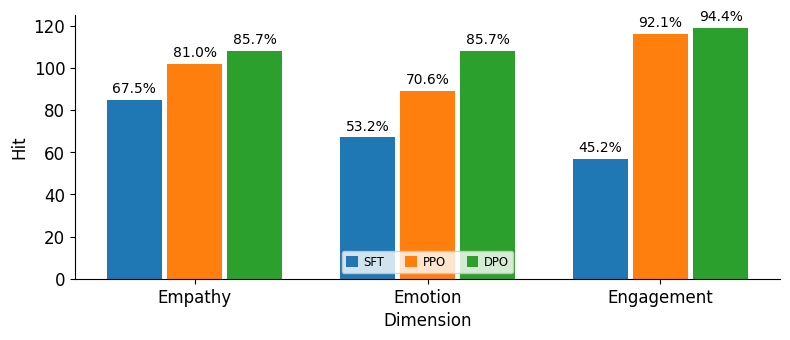

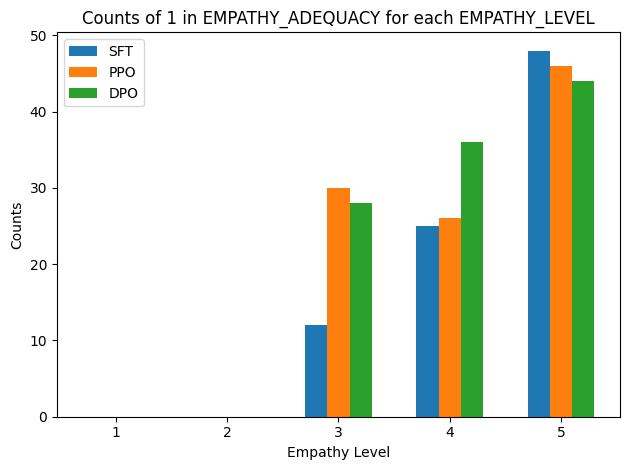

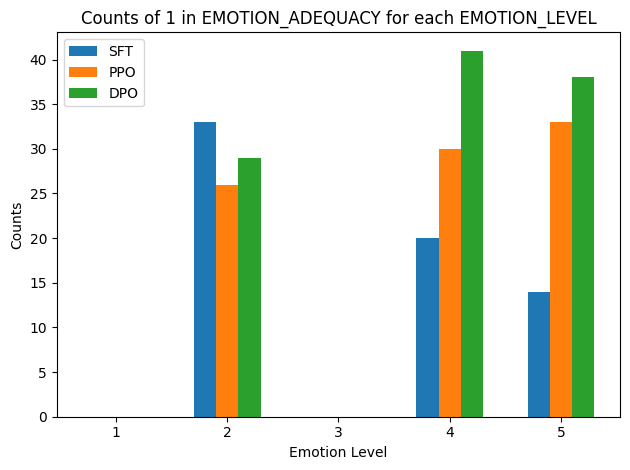

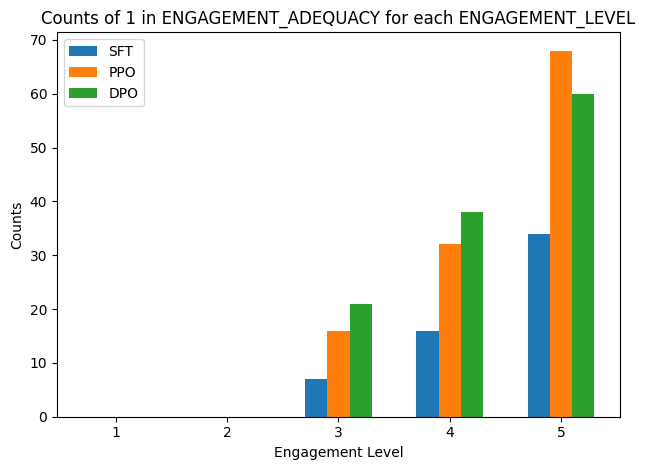

In [6]:
annotators = DEFAULT_ANNOTATORS
data_test_df, anno_t1, anno_t2 = run(annotators)

## Inspect Dataframes

In [7]:
print("data_test_df:", data_test_df.shape)
print("task1 annotations:", anno_t1.shape)
print("task2 annotations:", anno_t2.shape)

display(anno_t1.head())
display(anno_t2.head())
anno_t2["RESPONSE_TYPE"].value_counts()

data_test_df: (392, 76)
task1 annotations: (616, 12)
task2 annotations: (378, 15)


,DID,USER_T1,CHATBOT_T1,USER_T2,CHATBOT_T2,USER_T3,RESPONSE_1,RESPONSE_2,RESPONSE_3,RESPONSE_1_RANK,RESPONSE_2_RANK,RESPONSE_3_RANK
0,GPT4-000013,"(HAPPINESS) Maybe, I just love their never-giv...",(EMPATHY) Me too! They're so resilient. (NEUTR...,(SADNESS) I hope so. It's sad seeing them lose...,"(EMPATHY) I agree, it's definitely heartbreaki...",(ANGER) They better be; the fans are not happy.,(EMPATHY) I understand. They need to step up t...,"(EMPATHY) Totally, they're putting so much pre...",(EMPATHY) I completely understand the fans' an...,3,2,1.0
1,GPT4-000022,(FEAR) I fear that all classic songs will beco...,"(EMPATHY) That's a valid concern, classic song...","(SURPRISE) Actually yes, I introduced The Beat...",(EMPATHY) Really? That's unexpectedly wonderfu...,"(DISGUST) No, he just skips through their best...",(EMPATHY) I can see why that would be so disap...,(EMPATHY) It's disheartening that he doesn't a...,"(EMPATHY) That's absolutely repulsive, I can s...",3,2,1.0
2,GPT4-000026,"(DISGUST) I did. However, the counselor was of...",(EMPATHY) That's disappointing. (DISGUST) They...,"(SURPRISE) Actually, I've found a mentorship p...",(EMPATHY) That's great news! (DISGUST) It's a ...,"(ANGER) Well, I'm annoyed at myself too. I sho...",(EMPATHY) It's frustrating when you feel like ...,(EMPATHY) It's understandable to feel that way...,(EMPATHY) It's completely justifiable to feel ...,3,2,1.0
3,GPT4-000040,(SURPRISE) I've just found an extremely rare p...,"(EMPATHY) Wow, that's exciting! Rare plants ca...",(DISGUST) I saw my neighbor is using plastic p...,"(EMPATHY) Oh, that's not a pleasing sight for ...","(SADNESS) Unfortunately, some of my new planti...","(EMPATHY) I'm sorry to hear that, it's disappo...","(EMPATHY) That's disheartening to hear, garden...","(EMPATHY) Oh no, that must be really dishearte...",3,2,1.0
4,GPT4-000041,"(DISGUST) I have, but the quotes I received we...",(EMPATHY) It's frustrating how the rates can s...,"(DISGUST) Yes, but all they suggest are cactus...","(EMPATHY) I see, they're not everyone's cup of...","(DISGUST) I tried growing roses, but they got ...","(EMPATHY) That's awful, they're such beautiful...","(EMPATHY) Ugh, aphids are the worst, they can ...","(EMPATHY) Oh no, that's absolutely revolting! ...",1,2,3.0


,DID,USER_T1,CHATBOT_T1,USER_T2,CHATBOT_T2,USER_T3,RESPONSE,EXPRESSION_LEVEL,EMPATHY_ADEQUACY,EMOTION_ADEQUACY,ENGAGEMENT_ADEQUACY,RESPONSE_TYPE,EMPATHY_LEVEL,EMOTION_LEVEL,ENGAGEMENT_LEVEL
0,GPT4-001818,(DISGUST) I heard people spend thousands just ...,"(EMPATHY) It's insane, isn't it? (SADNESS) It'...",(SURPRISE) I've been researching and came acro...,(EMPATHY) Really? What's the name? (FEAR) That...,"(FEAR) Not yet, but I wouldn't mind.",(EMPATHY) It's always good to try new things. ...,"[5, 2, 5]",0,1,1,SFT_TEST,5,2,5
1,GPT4-001819,(SADNESS) I'd love to wear a haute couture dre...,"(EMPATHY) Yeah, they're definitely not budget-...",(HAPPINESS) That's not a bad idea! I never con...,(EMPATHY) Second-hand can be great and unique!...,"(FEAR) I haven't yet, but I'm open to suggesti...",(EMPATHY) I totally understand it can be daunt...,"[5, 2, 5]",1,0,1,DPO_TEST,5,2,5
2,GPT4-001827,"(FEAR) I've thought about it, but I'm afraid o...","(EMPATHY) That's definitely a valid fear, but ...","(NEUTRAL) Actually, I have! Any suggestions on...",(EMPATHY) Great! Some simple healthy food opti...,"(SURPRISE) I was skeptical at first, but I tri...","(EMPATHY) That's amazing, I'm genuinely deligh...","[4, 4, 4]",1,1,1,DPO_TEST,4,4,4
3,GPT4-001831,(ANGER) They only have one dessert option on t...,(EMPATHY) That's disappointing. I was looking ...,"(SURPRISE) This dessert is amazing, have you t...","(EMPATHY) Not yet, I was hesitant to order it....",(HAPPINESS) This restaurant has the best desse...,(EMPATHY) That's great to hear! I'm so glad yo...,"[3, 5, 3]",0,0,0,PPO_TEST,3,5,3
4,GPT4-001833,"(HAPPINESS) Yes, I just tried smoking meats in...",(EMPATHY) That's amazing! (ANGER) I can't beli...,"(DISGUST) I tried pan-searing cauliflower, but...","(EMPATHY) Oh no, that's too bad. (HAPPINESS) Y...","(DISGUST) Yes, I tried boiling brussels sprout...","(EMPATHY) Ugh, that's definitely not ideal. (F...","[4, 2, 4]",1,1,1,PPO_TEST,4,2,4


RESPONSE_TYPE
SFT_TEST    126
DPO_TEST    126
PPO_TEST    126
Name: count, dtype: int64